In [ ]:
# @title 1. Install & Connect
!pip install neo4j pandas networkx matplotlib scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 6.6 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from neo4j import GraphDatabase

# ENTER CREDENTIALS
URI = "neo4j+s://ccf24920.databases.neo4j.io"
AUTH = ("neo4j", "YHXssrChTu3r3FinSLYiNVUBhXoUEjcUDM-h0ERxD1E")

driver = GraphDatabase.driver(URI, auth=AUTH)

In [ ]:
def run_query(query, params={}):
    """Helper to run Cypher and return a clean Pandas DataFrame"""
    with driver.session() as session:
        result = session.run(query, params)
        data = [r.data() for r in result]
        return pd.DataFrame(data)

print("Ready to query!")

Ready to query!


In [ ]:
# @title 2. Key Insights (Tables)

print("Top 10 Most Referenced Articles (Degree Centrality)")
# We count how many times an Article is referenced by others
df_centrality = run_query("""
    MATCH (t:Article)<-[:REFERENCES]-(s)
    RETURN t.id as Article, count(s) as Mentions
    ORDER BY Mentions DESC
    LIMIT 10
""")
display(df_centrality)

Top 10 Most Referenced Articles (Degree Centrality)


,Article,Mentions
0,Art_101,13
1,Art_296,4
2,Art_133,3
3,Art_269,3
4,Art_87,3
5,Art_57,3
6,Art_178,3
7,Art_56,3
8,Art_207,2
9,Art_76,2


In [ ]:
print("\nKey Institutions (By Governance Responsibility)")
# We count how many Articles/Clauses mention an Institution
df_inst = run_query("""
    MATCH (i:Institution)<-[:GOVERNS]-(n)
    RETURN i.name as Institution, count(n) as Mentions
    ORDER BY Mentions DESC
""")
display(df_inst)



Key Institutions (By Governance Responsibility)


,Institution,Mentions
0,President,124
1,Federal Parliament,93
2,Supreme Court,52
3,Prime Minister,49
4,Election Commission,19


In [ ]:
print("\nDominant Fundamental Rights (By Complexity)")
# Which Right has the most clauses? (More clauses = More complex/dominant)
df_rights = run_query("""
    MATCH (a:FundamentalRight)-[:HAS_CLAUSE]->(c:Clause)
    RETURN a.id as Article, count(c) as Clause_Count
    ORDER BY Clause_Count DESC
    LIMIT 5
""")
display(df_rights)


Dominant Fundamental Rights (By Complexity)


,Article,Clause_Count
0,Art_308,24
1,Art_298,14
2,Art_286,12
3,Art_273,12
4,Art_274,9


What does the Constitution care about? (Topic Frequency)


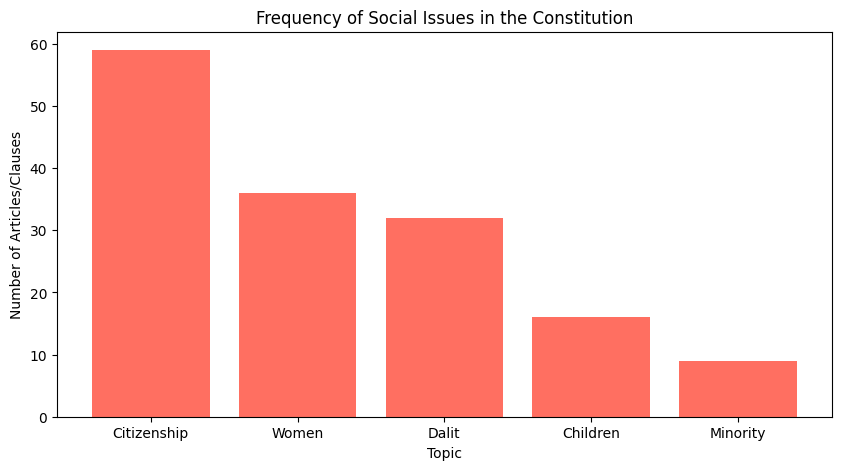

In [ ]:
# @title 5. Advanced Insights (Topics & Structure)

# --- Insight A: "Hot Topics" Analysis (Tag Counts) ---
print("What does the Constitution care about? (Topic Frequency)")
# We generated these tags in Day 1 based on keywords
df_tags = run_query("""
    MATCH (t:Tag)<-[:TAGGED]-(n)
    RETURN t.name as Topic, count(n) as Frequency
    ORDER BY Frequency DESC
""")

# Let's plot this one because tables are boring for frequency data
if not df_tags.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(df_tags['Topic'], df_tags['Frequency'], color='#FF6F61')
    plt.title("Frequency of Social Issues in the Constitution")
    plt.xlabel("Topic")
    plt.ylabel("Number of Articles/Clauses")
    plt.show()
else:
    print("No tags found (Did you run the enrichment step in Day 1?)")


In [ ]:
#  Insight C: The "Cross-Part" Interaction Matrix
print("Which Part of the constitution references other Parts the most?")

df_interactions = run_query("""
    MATCH (p1:Part)-[:HAS_ARTICLE]->(a1)-[:REFERENCES]->(a2)<-[:HAS_ARTICLE]-(p2:Part)
    WHERE p1 <> p2 // Ignore self-references (Part 1 referencing Part 1)
    RETURN p1.id as Source_Part, p2.id as Target_Part, count(*) as Connections
    ORDER BY Connections DESC
    LIMIT 10
""")
display(df_interactions)

Which Part of the constitution references other Parts the most?


,Source_Part,Target_Part,Connections
0,Part-3,Part-5,3
1,Part-3,Part-15,2
2,Part-3,Part-13,2
3,Part-3,Part-18,2
4,Part-3,Part-20,2
5,Part-3,Part-17,2
6,Part-6,Part-8,2
7,Part-3,Part-9,1
8,Part-35,Part-1,1
9,Part-11,Part-8,1


In [ ]:
# @title 3. Visualize Citation Network (Part 3 Only)

# Get edges where both Source and Target are in Part-3 (Fundamental Rights)
df_edges = run_query("""
    MATCH (s:Article)-[:REFERENCES]->(t:Article)
    WHERE s.id CONTAINS 'Art_' AND t.id CONTAINS 'Art_'
    // Filter to keep the chart readable (optional)
    RETURN s.id as source, t.id as target
    LIMIT 100
""")

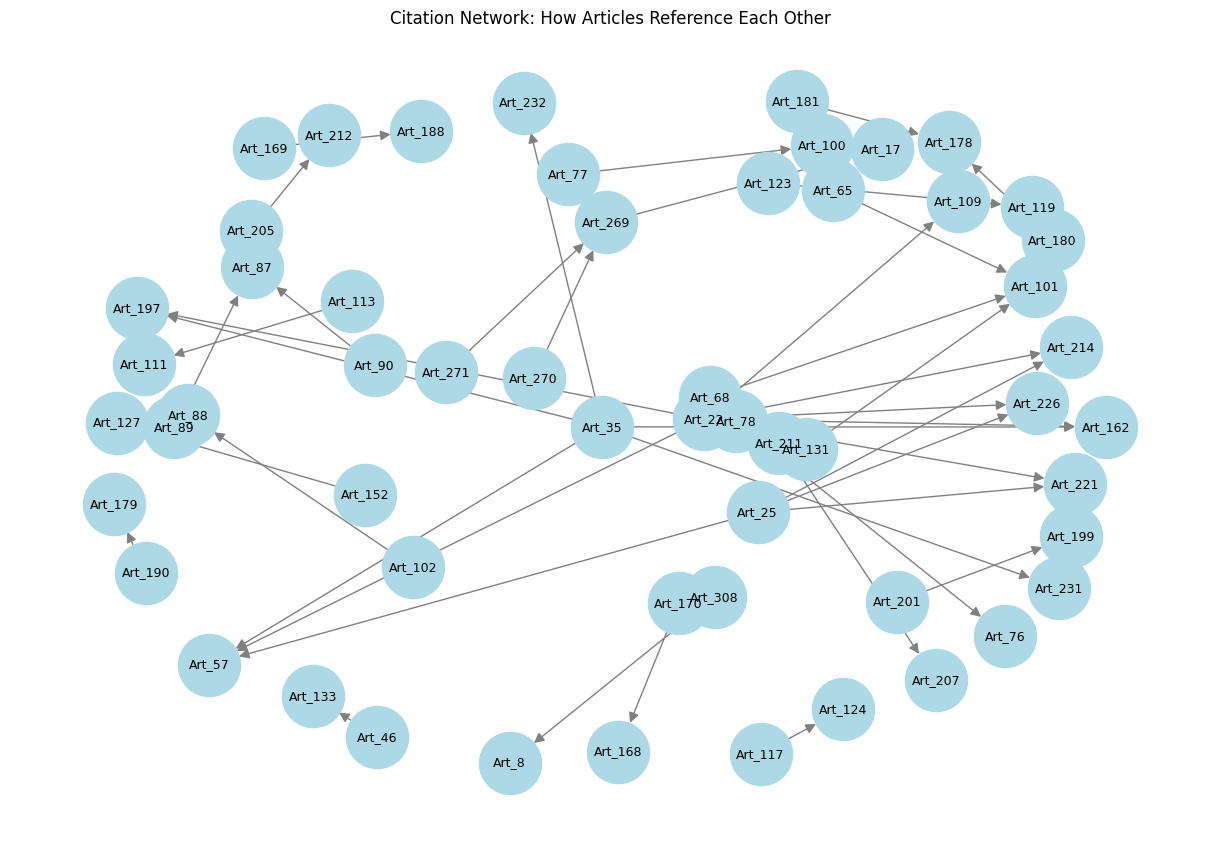

In [ ]:
# Build Graph
G = nx.DiGraph()
for _, row in df_edges.iterrows():
    G.add_edge(row['source'], row['target'])

# Draw
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw(G, pos,
        with_labels=True,
        node_color='lightblue',
        edge_color='gray',
        node_size=2000,
        font_size=9,
        arrowsize=15)

plt.title("Citation Network: How Articles Reference Each Other")
plt.show()

In [ ]:
# @title 4. Simple Recommendation Engine

target_article = "Art_17" # Right to Freedom

print(f" Recommendations for: {target_article}")

# Logic: Find articles that reference the SAME things that Art_17 references
# (i.e., "Bibliographic Coupling")
df_recs = run_query("""
    MATCH (source:Article {id: $id})-[:REFERENCES]->(common)
    MATCH (other:Article)-[:REFERENCES]->(common)
    WHERE source <> other
    RETURN other.id as Recommended_Article, count(common) as Shared_References
    ORDER BY Shared_References DESC
    LIMIT 5
""", {"id": target_article})

if not df_recs.empty:
    display(df_recs)
else:
    print("No strong recommendations found based on citations alone.")

 Recommendations for: Art_17
No strong recommendations found based on citations alone.


In [ ]:
# @title 4. Recommendation Engine (2-Hop Queries)

def get_recommendations(article_id):
    query = """
    MATCH (source:Article {id: $id})

    // Strategy 1: Citations (Articles that cite this one)
    OPTIONAL MATCH (source)<-[:REFERENCES]-(citing)

    // Strategy 2: Shared Topic Tags
    OPTIONAL MATCH (source)-[:TAGGED]->(t:Tag)<-[:TAGGED]-(related)

    // Strategy 3: Co-Citation (Articles referenced by the same source)
    OPTIONAL MATCH (source)<-[:REFERENCES]-(common)-[:REFERENCES]->(cousin)
    WHERE cousin <> source

    // Aggregate & Score
    WITH coalesce(citing, related, cousin) as rec,
         count(*) as score,
         collect(distinct labels(coalesce(citing, related, cousin))) as type
    WHERE rec IS NOT NULL
    RETURN rec.id as Article, score as Relevance
    ORDER BY score DESC
    LIMIT 5
    """
    return run_query(query, {"id": article_id})

In [ ]:
target = "Art_17"
recs = get_recommendations(target)
print(recs)

      Article  Relevance
0     Art_269          7
1  Art_273.10          7


In [ ]:
# @title 6. Components & 2-Hop

# --- TASK A: Compute Components (The "Islands" Math) ---
print("Computing Graph Components...")
# 1. Get all citation edges
df_all_refs = run_query("MATCH (s:Article)-[:REFERENCES]->(t:Article) RETURN s.id as u, t.id as v")


Computing Graph Components...


In [ ]:
# 2. Build Graph
G_full = nx.DiGraph()
G_full.add_edges_from(zip(df_all_refs['u'], df_all_refs['v']))

In [ ]:
# 3. Calculate Weakly Connected Components (Islands)
# "Weakly" means we ignore arrow direction (just looking for connection)
components = list(nx.weakly_connected_components(G_full))

In [ ]:
print(f"Total Disconnected 'Components' of Law: {len(components)}")
print(f"(This means there are {len(components)} groups of articles that don't talk to each other at all)")

Total Disconnected 'Components' of Law: 20
(This means there are 20 groups of articles that don't talk to each other at all)


In [ ]:
print(f"Largest Interconnected Article Size: {len(max(components, key=len))}")
print(f"At most {len(max(components, key=len))} other articles is referenced by one article")

Largest Interconnected Article Size: 12
At most 12 other articles is referenced by one article


In [ ]:
# TASK C: The "Centrality" Score (Degree)
# Just to be 100% sure we computed it explicitly as requested
print("CENTRALITY SCORES (Degree)")
print(f"Average In-Degree (Citations received): {sum(dict(G_full.in_degree()).values()) / G_full.number_of_nodes():.2f}")

CENTRALITY SCORES (Degree)
Average In-Degree (Citations received): 0.73


In [ ]:
# article-article referneces Include Clause → Article → Article
df_2hop = run_query("""
MATCH (c:Clause)<-[:HAS_CLAUSE]-(a:Article)
MATCH (c)-[:REFERENCES]->(b:Article)
MATCH (b)-[:REFERENCES]->(d:Article)
RETURN a.id AS Start_Article,
       b.id AS Bridge_Article,
       d.id AS End_Article
LIMIT 20

""")

display(df_2hop)

,Start_Article,Bridge_Article,End_Article
0,Art_271,Art_269,Art_17
1,Art_273,Art_46,Art_133


In [ ]:
# article-article referneces Include Clause → Article → Article
df_2hop = run_query("""
MATCH (a:Article)-[:REFERENCES]->(b:Article)
MATCH (c:Article)-[:REFERENCES]->(b)
WHERE a <> c
RETURN a.id AS Article_A,
       b.id AS Shared_Article,
       c.id AS Article_C
LIMIT 10
""")

display(df_2hop)

,Article_A,Shared_Article,Article_C
0,Art_68,Art_101,Art_65
1,Art_131,Art_101,Art_65
2,Art_65,Art_101,Art_68
3,Art_131,Art_101,Art_68
4,Art_90,Art_87,Art_89
5,Art_89,Art_87,Art_90
6,Art_65,Art_101,Art_131
7,Art_68,Art_101,Art_131
8,Art_181,Art_178,Art_180
9,Art_180,Art_178,Art_181


In [ ]:
# --- TASK B: 2-Hop Article Relationships (Chain of Command) ---
print("2-Hop Cross-References (Chain: A -> B -> C)")
print("Showing how Law A affects Law C through Law B")

# Cypher for explicit 2-hops
df_2hop = run_query("""
    MATCH (a:Article)-[:REFERENCES]->(b:Article)-[:REFERENCES]->(c:Article)
    WHERE a <> c
    RETURN a.id as Start_Article,
           b.id as Bridge_Article,
           c.id as End_Article
    LIMIT 10
""")

display(df_2hop)

2-Hop Cross-References (Chain: A -> B -> C)
Showing how Law A affects Law C through Law B


,Start_Article,Bridge_Article,End_Article
0,Art_270,Art_269,Art_17
1,Art_271,Art_269,Art_17
